In [31]:
import os
from pathlib import Path

import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from rasterio.plot import show
from rasterio.features import shapes
from pysheds.grid import Grid

import matplotlib.pyplot as plt

In [14]:
# Paths
root = Path("c:/Users/Administrator/PythonProjects/abfluss_queich")
data_root = root / "data"

dtm_dir = data_root / "DTM_rlp"
dtm_path = dtm_dir / "DTM Germany_Rheinland-Pfalz 20m.tif"
dtm_crop_path = dtm_dir / "dtm_crop.tif"

print(dtm_path)
print(dtm_crop_path)

c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\DTM Germany_Rheinland-Pfalz 20m.tif
c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\dtm_crop.tif


In [ ]:
# --- Create ROI DTM ---

# ROI in UTM32N
minx, miny, maxx, maxy = 400264, 5436526, 440273, 5465599

# Open DTM read window only and save crop
with rasterio.open(dtm_path) as src:
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    
    cropped = src.read(1, window=window)
    transform = src.window_transform(window)
    
    profile = src.profile.copy()
    profile.update({
        "height": cropped.shape[0],
        "width": cropped.shape[1],
        "transform": transform
    })

output_path = dtm_dir / "dtm_crop.tif"

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(cropped, 1)

In [16]:
# --- PYSHED ---

# Read tif as pysed raster
grid = Grid.from_raster(str(dtm_crop_path))
dem = grid.read_raster(str(dtm_crop_path))

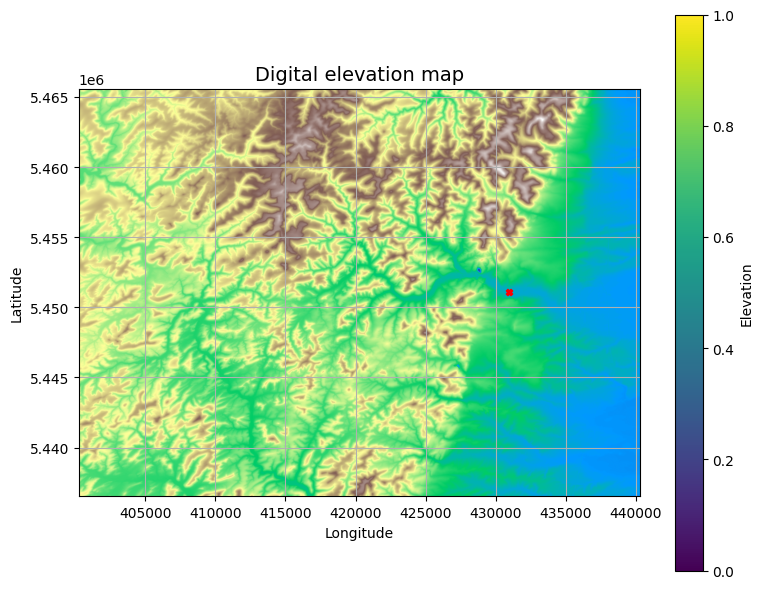

In [25]:
# Plot ROI and Siebeldingen
x, y =  430911, 5451088 # Siebeldingen

# Convert UTM32N in row/col indices
row, col = rowcol(grid.affine, x, y)

# Check DTM
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='terrain', zorder=1)
plt.scatter(x, y, c="red", s=20, marker="X")
plt.colorbar(label='Elevation')
plt.grid(zorder=0)
plt.title('Digital elevation map', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

In [26]:
# --- Condition DEM ---

# Fill pits & depressions in DEM
pit_filled_dem = grid.fill_pits(dem)
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)


# --- Determine D8 flow directions from DEM

# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

# Calculate flow accumulation
acc = grid.accumulation(fdir, dirmap=dirmap)

In [27]:
# Delineate a catchment
# ---------------------
# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(mask=acc > 1000, xy=(x, y))

# Delineate the catchment
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                       xytype='coordinate')

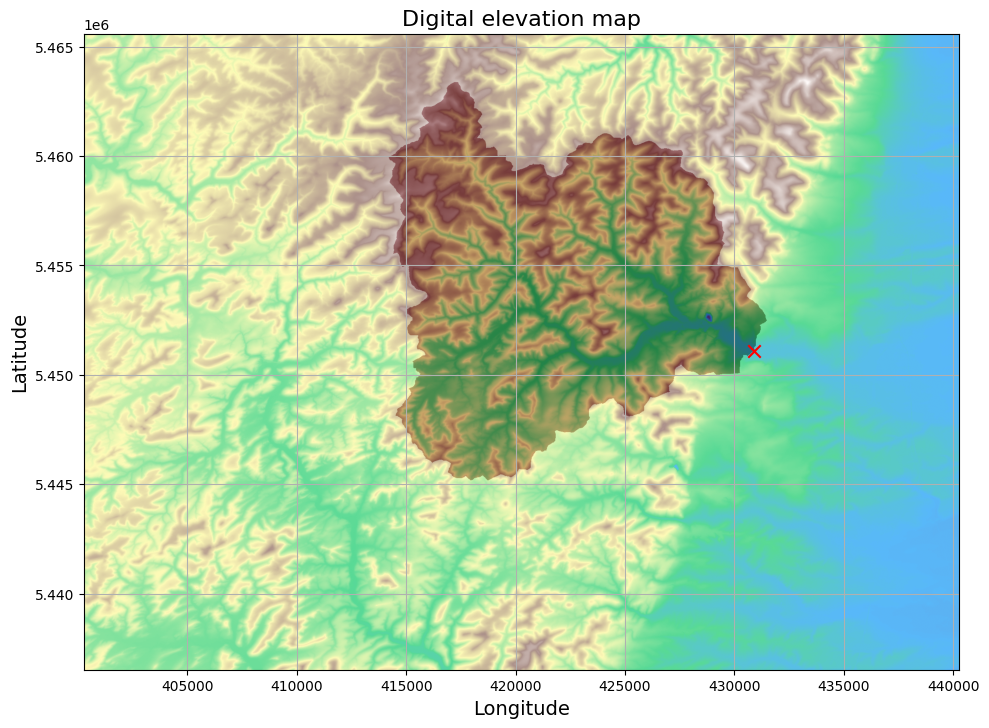

In [28]:
# Check result
fig, ax = plt.subplots(figsize=(10,8))

show(dem, extent=grid.extent, ax=ax, cmap="terrain")
show(catch, extent=grid.extent, ax=ax, cmap="Reds", alpha=0.35)
ax.scatter(x, y, s=80, c="red", marker="x")

plt.grid(zorder=0)
plt.title('Digital elevation map', size=16)
plt.xlabel('Longitude', size=14)
plt.ylabel('Latitude', size=14)
plt.tight_layout()

plt.show()

In [ ]:
# --- Export as GPKG ---

# Get metadata
with rasterio.open(dtm_path) as src:
    crs = src.crs
    transform = src.transform


# Create features
mask = catch.astype("uint8")

results = (
    {"properties": {"value": v}, "geometry": s}
    for s, v in shapes(mask, mask=mask, transform=grid.affine)
)

# Export as gpgk
output_path = dtm_dir / "catchment_queich_siebeldingen.gpkg"

gdf = gpd.GeoDataFrame.from_features(list(results), crs=grid.crs)
gdf.to_file(output_path, driver="GPKG")

In [ ]:
# Extract river network
# ---------------------
branches = grid.extract_river_network(fdir, acc > 50, dirmap=dirmap)

In [ ]:
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)